In [1]:
import pandas as pd

df = pd.read_csv("titanic.csv")

print("Data loaded")
print("Shape:", df.shape)

Data loaded
Shape: (889, 14)


In [3]:
#Prepare data for the model

X = df.drop(columns=["survived"])
y = df["survived"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (889, 13)
y shape: (889,)


In [4]:
# Check survival class balance
print("Survival count:")
print(y.value_counts())

print("\nSurvival percentage:")
print((y.value_counts(normalize=True) * 100).round(2))

Survival count:
survived
0    549
1    340
Name: count, dtype: int64

Survival percentage:
survived
0    61.75
1    38.25
Name: proportion, dtype: float64


In [5]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (711, 13)
Testing data: (178, 13)


In [6]:
print("Training survival rate:", round(y_train.mean() * 100, 2), "%")
print("Testing survival rate:", round(y_test.mean() * 100, 2), "%")

Training survival rate: 38.26 %
Testing survival rate: 38.2 %


In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [8]:
numeric_features = ["age", "sibsp", "parch", "fare"]
categorical_features = ["sex", "embarked"]

In [9]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [10]:
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [11]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Training data:", X_train_processed.shape)
print("Testing data:", X_test_processed.shape)

Training data: (711, 9)
Testing data: (178, 9)


In [12]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_processed, y_train)

print("Logistic Regression done")

Logistic Regression done


In [13]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train_processed, y_train)

print("Decision Tree done")

Decision Tree done


In [14]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(random_state=42)

forest_model.fit(X_train_processed, y_train)

print("Random Forest done")

Random Forest done


In [15]:
logistic_pred = logistic_model.predict(X_test_processed)
tree_pred = tree_model.predict(X_test_processed)
forest_pred = forest_model.predict(X_test_processed)

print("Predictions done")

Predictions done


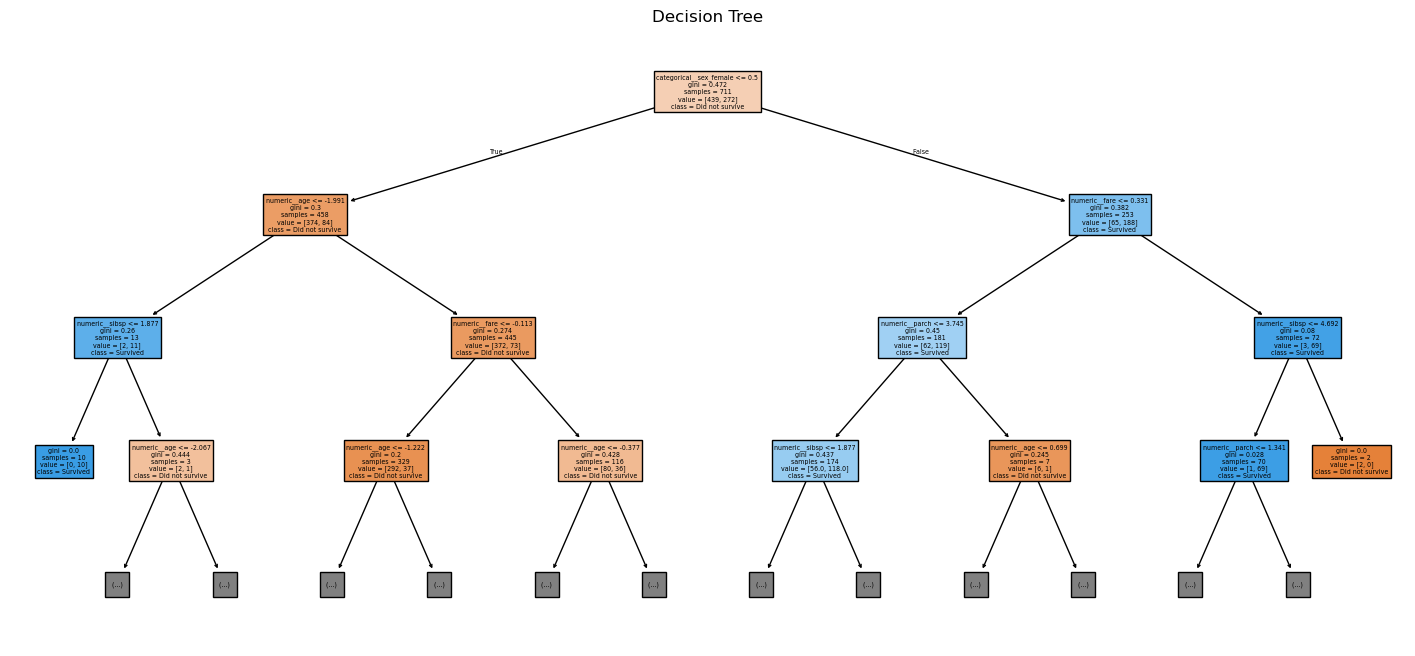

In [16]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

feature_names = preprocessor.get_feature_names_out()

plt.figure(figsize=(18, 8))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["Did not survive", "Survived"],
    max_depth=3,
    filled=True
)

plt.title("Decision Tree")
plt.show()

In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

In [18]:
models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": tree_model,
    "Random Forest": forest_model
}

predictions = {
    "Logistic Regression": logistic_pred,
    "Decision Tree": tree_pred,
    "Random Forest": forest_pred
}

results = []

for name in models:
    pred = predictions[name]
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "AUC": roc_auc_score(
            y_test,
            models[name].predict_proba(X_test_processed)[:, 1]
        )
    })

results_df = pd.DataFrame(results)

display(results_df.round(3))

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.781,0.754,0.632,0.688,0.826
1,Decision Tree,0.770,0.714,0.662,0.687,0.741
2,Random Forest,0.798,0.776,0.662,0.714,0.821


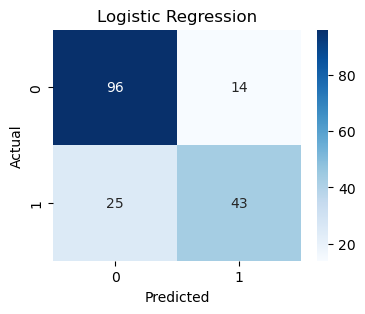

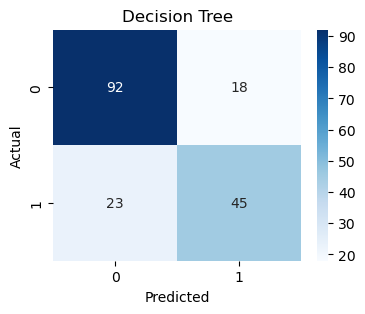

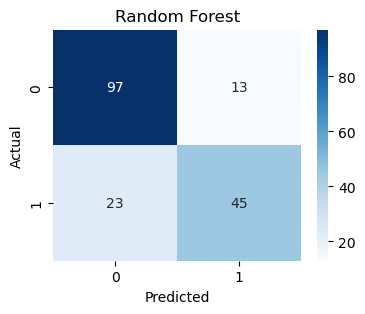

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
for name, pred in predictions.items():
    cm = confusion_matrix(y_test, pred)
    
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    
    plt.show()

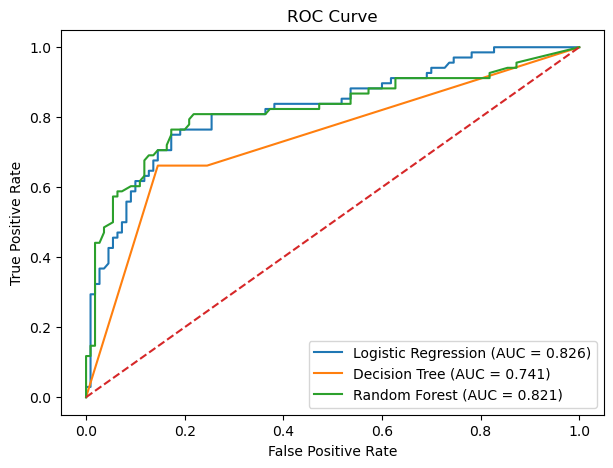

In [21]:
plt.figure(figsize=(7, 5))

for name, model in models.items():
    probabilities = model.predict_proba(X_test_processed)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    auc = roc_auc_score(y_test, probabilities)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

In [22]:
print("Class balance:")
print(y.value_counts())

print("\nPercentage:")
print((y.value_counts(normalize=True) * 100).round(2))

Class balance:
survived
0    549
1    340
Name: count, dtype: int64

Percentage:
survived
0    61.75
1    38.25
Name: proportion, dtype: float64


In [23]:
balanced_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

balanced_model.fit(X_train_processed, y_train)

balanced_pred = balanced_model.predict(X_test_processed)

print("Balanced model done")

Balanced model done


In [24]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_smote.value_counts().to_dict())

Before SMOTE: {0: 439, 1: 272}
After SMOTE: {1: 439, 0: 439}


In [25]:
smote_model = LogisticRegression(max_iter=1000)

smote_model.fit(X_train_smote, y_train_smote)

smote_pred = smote_model.predict(X_test_processed)

print("SMOTE model done")

SMOTE model done


In [26]:
imbalance_results = []

for name, pred in [
    ("Normal", logistic_pred),
    ("Balanced", balanced_pred),
    ("SMOTE", smote_pred)
]:
    imbalance_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred)
    })

imbalance_results_df = pd.DataFrame(imbalance_results)

display(imbalance_results_df.round(3))

,Model,Accuracy,Precision,Recall,F1
0,Normal,0.781,0.754,0.632,0.688
1,Balanced,0.798,0.750,0.706,0.727
2,SMOTE,0.792,0.746,0.691,0.718


In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    random_state=42,
    oob_score=True,
    bootstrap=True
)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train_processed, y_train)

print("Best parameters:")
print(rf_grid.best_params_)

print("Best CV F1:", round(rf_grid.best_score_, 3))

Best parameters:
{'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 100}
Best CV F1: 0.744


In [47]:
best_rf = rf_grid.best_estimator_

print("OOB score:", round(best_rf.oob_score_, 3))

OOB score: 0.807


In [48]:
rf_pred = best_rf.predict(X_test_processed)

print("Test Accuracy:", round(accuracy_score(y_test, rf_pred), 3))
print("Test Precision:", round(precision_score(y_test, rf_pred), 3))
print("Test Recall:", round(recall_score(y_test, rf_pred), 3))
print("Test F1:", round(f1_score(y_test, rf_pred), 3))

Test Accuracy: 0.803
Test Precision: 0.78
Test Recall: 0.676
Test F1: 0.724


Result: GridSearchCV found the best Random Forest parameters. The model had an OOB score of 0.807 and a test F1 score of 0.724.

In [55]:
# Prepare data for regression

X_reg = df.drop(columns=["fare", "survived"])
y_reg = df["fare"]

print("X shape:", X_reg.shape)
print("y shape:", y_reg.shape)

X shape: (889, 12)
y shape: (889,)


In [56]:
# Convert categorical columns to numbers

categorical_columns = X_reg.select_dtypes(include=["object", "category"]).columns

X_reg = pd.get_dummies(
    X_reg,
    columns=categorical_columns,
    drop_first=True
)

X_reg = X_reg.astype(float)

print("Regression features:", X_reg.shape)

Regression features: (889, 16)


In [57]:
print("Missing values:")
print(X_reg.isnull().sum().sum())

Missing values:
0


In [58]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_reg_train.shape)
print("Testing data:", X_reg_test.shape)

Training data: (711, 16)
Testing data: (178, 16)


In [59]:
from sklearn.linear_model import LinearRegression

reg_model = LinearRegression()

reg_model.fit(X_reg_train, y_reg_train)

reg_pred = reg_model.predict(X_reg_test)

print("Linear Regression done")

Linear Regression done


In [60]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_reg_test, reg_pred)

rmse = mean_squared_error(
    y_reg_test,
    reg_pred
) ** 0.5

r2 = r2_score(y_reg_test, reg_pred)

n = len(y_reg_test)
p = X_reg_test.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2:", round(r2, 3))
print("Adjusted R2:", round(adjusted_r2, 3))

MAE: 18.37
RMSE: 41.29
R2: 0.361
Adjusted R2: 0.297


Regression Result: The model has an R² of 0.361, so the features explain some of the variation in fare. The RMSE is 41.29, showing that there is still a fairly large prediction error.

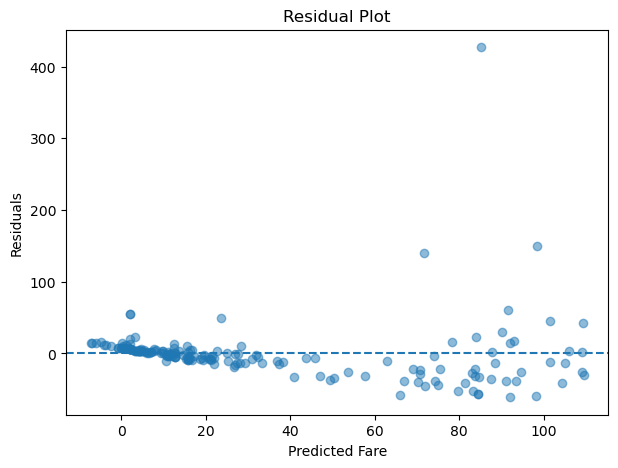

In [61]:
residuals = y_reg_test - reg_pred

plt.figure(figsize=(7, 5))

plt.scatter(reg_pred, residuals, alpha=0.5)
plt.axhline(0, linestyle="--")

plt.title("Residual Plot")
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")

plt.show()

Residual Plot Interpretation: The residuals are not spread evenly across the plot. The spread becomes larger for higher predicted fares, which suggests heteroscedasticity.

In [62]:
# Final classification results

final_classification = []

# Logistic Regression
logistic_pred = logistic_model.predict(X_test_processed)

final_classification.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, logistic_pred),
    "Precision": precision_score(y_test, logistic_pred),
    "Recall": recall_score(y_test, logistic_pred),
    "F1": f1_score(y_test, logistic_pred),
    "AUC": roc_auc_score(
        y_test,
        logistic_model.predict_proba(X_test_processed)[:, 1]
    )
})

# Decision Tree
tree_pred = tree_model.predict(X_test_processed)

final_classification.append({
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_test, tree_pred),
    "Precision": precision_score(y_test, tree_pred),
    "Recall": recall_score(y_test, tree_pred),
    "F1": f1_score(y_test, tree_pred),
    "AUC": roc_auc_score(
        y_test,
        tree_model.predict_proba(X_test_processed)[:, 1]
    )
})

# Tuned Random Forest
rf_pred = best_rf.predict(X_test_processed)

final_classification.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred),
    "Recall": recall_score(y_test, rf_pred),
    "F1": f1_score(y_test, rf_pred),
    "AUC": roc_auc_score(
        y_test,
        best_rf.predict_proba(X_test_processed)[:, 1]
    )
})

final_classification_df = pd.DataFrame(final_classification)

display(final_classification_df.round(3))

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.781,0.754,0.632,0.688,0.826
1,Decision Tree,0.770,0.714,0.662,0.687,0.741
2,Random Forest,0.803,0.780,0.676,0.724,0.826


In [63]:
final_regression_df = pd.DataFrame([{
    "Model": "Linear Regression",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
    "Adjusted R2": adjusted_r2
}])

display(final_regression_df.round(3))

,Model,MAE,RMSE,R2,Adjusted R2
0,Linear Regression,18.374,41.292,0.361,0.297


In [64]:
best_classifier_name = final_classification_df.loc[
    final_classification_df["F1"].idxmax(),
    "Model"
]

print("Best classifier:", best_classifier_name)

Best classifier: Random Forest


Final Recommendation: Random Forest is the best classifier for this dataset, with an accuracy of 0.803 and an F1 score of 0.724. It also has the highest precision of 0.780 among the three models. Its AUC is 0.826, showing good ability to separate the two classes. Based on these results, I would choose Random Forest as the final model.

In [65]:
from sklearn.pipeline import Pipeline
import joblib

final_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", best_rf)
])

print("Complete pipeline created")

Complete pipeline created


In [66]:
final_pipeline.fit(X_train, y_train)

print("Final pipeline trained")

Final pipeline trained


In [67]:
final_pred = final_pipeline.predict(X_test)

print("Final accuracy:", round(
    accuracy_score(y_test, final_pred), 3
))

print("Final F1:", round(
    f1_score(y_test, final_pred), 3
))

Final accuracy: 0.803
Final F1: 0.724


In [68]:
joblib.dump(
    final_pipeline,
    "best_model_pipeline.joblib"
)

print("Pipeline saved successfully")

Pipeline saved successfully


In [69]:
loaded_pipeline = joblib.load(
    "best_model_pipeline.joblib"
)

loaded_pred = loaded_pipeline.predict(X_test)

print("Loaded model accuracy:", round(
    accuracy_score(y_test, loaded_pred), 3
))

print("Loaded model F1:", round(
    f1_score(y_test, loaded_pred), 3
))

Loaded model accuracy: 0.803
Loaded model F1: 0.724
